# 15 · E4a: does the brain close on its own, or only with the body?

**Proposal E4** asks *where the closed level lives*: in the nervous system alone, in brain + body, or only in brain + body + environment. E1–E3 treated the brain as the system, with behavior either ignored or fed in as an observed input. This notebook asks the first half of E4 with the 68 Atanas et al. whole-brain recordings of freely moving worms. Each recording has neural activity plus four body variables: velocity, head angle, angular velocity, pumping.

| model | system | the body is… |
|---|---|---|
| `brain` | neural program alone | absent |
| `joint` | brain + body as **one closed system** | a state the model must predict (motor output → body; body → brain) |
| `open` | brain with the **observed** body as input | known from the measurement: not closed; an upper bound |
| `body-AR` | the body alone | its own past only |

Every model is run *autonomously* for k = 1, 5, 20 steps (0.6, 3 and 13 s) from the observed state, and scored on the k-step change of neural activity.

* If `joint` forecasts the brain better than `brain`, beyond a control in which behavior is circularly shifted (same statistics, no alignment), then the body is part of what makes the brain's dynamics self-contained: **the closed level includes the body**.
* If `open` ≫ `joint`, the observed body carries information about the brain's future that brain + body cannot generate themselves. That information enters the body from outside: the environment, or unrecorded neurons.

**Cross-validation.** Notebooks 10–14 showed that programs drift over minutes, so a model fitted on one half fails on the other (negative R²). Training and test therefore use **interleaved blocks**: 10 blocks of ~1.7 min, with block i in fold i mod 5, so drift affects both equally. The behavior shift is 0.37 of the recording, because a shift of 0.5 would map blocks onto blocks of the same fold.

On one recording (2021-05-26-07), at k = 20:
* `brain` scored 0.171, `joint` 0.182 and `open` 0.303;
* shifted behavior gave `joint` 0.191: the slow structure of any behavior trace helps a little at long horizons. This is why the registered rule averages over horizons and is paired against the shifted control.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, time, datetime, numpy as np, matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 13, 0), \
    f"Notebook 15 needs closurebench >= 0.13.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import drift as DR, embodiment as EM
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {"smoke": dict(MAX_FILES=1), "laptop": dict(MAX_FILES=None), "full": dict(MAX_FILES=None)}[MODE]
globals().update(CONF)
KS, SHIFT = EM.HORIZONS, 0.37
TAG = "" if MODE == "full" else f"_{MODE}"
files = sorted(glob.glob(os.path.join(RESULTS, "spontaneous", "*.json")))[:MAX_FILES]
CK = os.path.join(RESULTS, "e4a_ck", MODE); os.makedirs(CK, exist_ok=True)
print(f"{len(files)} recordings; horizons {KS} steps; behavior shift {SHIFT}")

68 recordings; horizons (1, 5, 20) steps; behavior shift 0.37


### Pre-registration (before §1)

Recorded in `results/E4a_preregistration*.json`. All statistics are averaged over the horizons k = 1, 5, 20, and the tests run over recordings.

* **BODY_CLOSES.** mean_k[R²_joint − R²_joint(shifted)] > 0 (one-sided Wilcoxon, p < 0.05) **and** median mean_k[R²_joint − R²_brain] > 0.
* **BODY_INFORMATIVE.** mean_k[R²_open − R²_open(shifted)] > 0 (one-sided Wilcoxon, p < 0.05): the observed body carries information about the brain's future.
* **BRAIN_DRIVES_BODY.** mean_k[(R²_body,joint − R²_body,AR) − (same with shifted behavior)] > 0 (one-sided Wilcoxon, p < 0.05): the brain helps predict the body.
* Descriptive: the **closure share** at k = 20, (joint − brain)/(open − brain), i.e. the fraction of the observed body's information that the closed brain + body model generates itself. It is computed only where open − brain > 0.01.

In [3]:
prereg = os.path.join(RESULTS, f"E4a_preregistration{TAG}.json")
plan = {"experiment": "E4a brain vs brain + body", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "config": {**CONF, "KS": list(KS), "SHIFT": SHIFT, "cv": "10 interleaved blocks, 5 folds"},
        "BODY_CLOSES": "one-sided Wilcoxon mean_k(joint - joint_shift) > 0, p < 0.05, and median mean_k(joint - brain) > 0",
        "BODY_INFORMATIVE": "one-sided Wilcoxon mean_k(open - open_shift) > 0, p < 0.05",
        "BRAIN_DRIVES_BODY": "one-sided Wilcoxon mean_k((body_joint - body_ar) - shifted) > 0, p < 0.05",
        "closure_share": "(joint - brain)/(open - brain) at k = 20 where open - brain > 0.01 (descriptive)"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E4a_preregistration_laptop.json


## 1 · Per-recording analysis (checkpointed)

About 30–60 s per recording on a laptop.

In [4]:
rec = {}
for f in files:
    name = os.path.basename(f).replace(".json", "")[-13:]
    ck = os.path.join(CK, name + ".json")
    if os.path.exists(ck):
        rec[name] = json.load(open(ck)); continue
    t0 = time.time()
    R = DR.load_atanas(f); X, U = R["X"], R["U"]
    if U is None:
        print(f"{name}: no behavior, skipped"); continue
    S = ~np.eye(X.shape[1], dtype=bool)
    out = {"N": int(X.shape[1]), "real": EM.embodiment_scores(X, U, S, KS), "shift": EM.embodiment_scores(X, U, S, KS, shift_frac=SHIFT)}
    json.dump(out, open(ck, "w"), default=float); rec[name] = out
    r, s = out["real"], out["shift"]; k = str(KS[-1]) if isinstance(next(iter(r["brain"])), str) else KS[-1]
    print(f"{name}: k={KS[-1]}: brain {r['brain'][k]:.3f} | joint {r['joint'][k]:.3f} (shifted {s['joint'][k]:.3f}) | open {r['open'][k]:.3f} (shifted {s['open'][k]:.3f})"
          f" | body: joint {r['body_joint'][k]:.3f} vs AR {r['body_ar'][k]:.3f}  ({time.time() - t0:.0f} s)", flush=True)
print(f"{len(rec)} recordings analysed")

2021-05-26-07: k=20: brain 0.171 | joint 0.182 (shifted 0.191) | open 0.303 (shifted 0.188) | body: joint 0.454 vs AR 0.331  (30 s)
2021-06-11-01: k=20: brain -0.000 | joint 0.035 (shifted 0.039) | open 0.171 (shifted 0.035) | body: joint 0.323 vs AR 0.308  (36 s)
2021-08-04-06: k=20: brain 0.288 | joint 0.302 (shifted 0.285) | open 0.363 (shifted 0.285) | body: joint 0.389 vs AR 0.333  (36 s)
2021-08-17-01: k=20: brain 0.237 | joint 0.246 (shifted 0.232) | open 0.315 (shifted 0.228) | body: joint 0.404 vs AR 0.357  (31 s)
2021-08-18-01: k=20: brain 0.160 | joint 0.203 (shifted 0.151) | open 0.339 (shifted 0.144) | body: joint 0.443 vs AR 0.394  (28 s)
2021-09-06-09: k=20: brain 0.128 | joint 0.178 (shifted 0.124) | open 0.303 (shifted 0.113) | body: joint 0.364 vs AR 0.332  (30 s)
2021-09-14-01: k=20: brain 0.245 | joint 0.250 (shifted 0.243) | open 0.311 (shifted 0.242) | body: joint 0.301 vs AR 0.349  (31 s)
2021-09-14-05: k=20: brain 0.229 | joint 0.231 (shifted 0.220) | open 0.310

68 recordings
median R² of the neural k-step change:
  k= 1: brain 0.118 | joint 0.125 (shifted 0.111) | open 0.125 (shifted 0.111)
  k= 5: brain 0.233 | joint 0.250 (shifted 0.233) | open 0.279 (shifted 0.232)
  k=20: brain 0.268 | joint 0.294 (shifted 0.272) | open 0.384 (shifted 0.273)

BODY_CLOSES:       joint - shifted +0.0148 (positive in 60/68, p = 1.3e-08); joint - brain +0.0128 -> True
BODY_INFORMATIVE:  open - shifted  +0.0572 (positive in 68/68, p = 3.82e-13) -> True
BRAIN_DRIVES_BODY: body gain from brain, beyond shifted +0.0810 (positive in 66/68, p = 5.22e-13) -> True
closure share at k=20 (fraction of the observed body's information the closed model generates): median +0.13 over 68 recordings


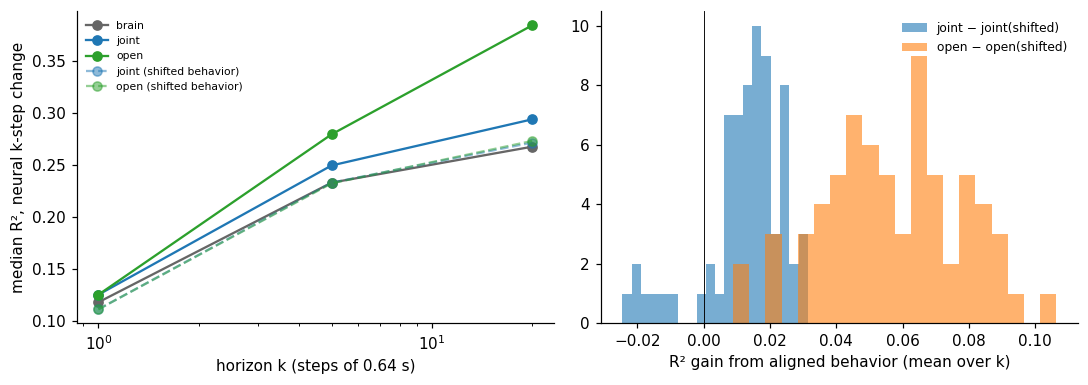

In [5]:
def wtest(x, alt="greater"):
    x = np.asarray(x, float)
    return float(wilcoxon(x, alternative=alt).pvalue) if len(x) >= 6 and np.any(x != 0) else float("nan")
def g(d, m, k):
    return d[m][str(k)] if str(k) in d[m] else d[m][k]
def mk(o, fn):
    return float(np.mean([fn(o, k) for k in KS]))
d_close = np.array([mk(o, lambda o, k: g(o["real"], "joint", k) - g(o["shift"], "joint", k)) for o in rec.values()])
d_jb = np.array([mk(o, lambda o, k: g(o["real"], "joint", k) - g(o["real"], "brain", k)) for o in rec.values()])
d_open = np.array([mk(o, lambda o, k: g(o["real"], "open", k) - g(o["shift"], "open", k)) for o in rec.values()])
d_b2b = np.array([mk(o, lambda o, k: (g(o["real"], "body_joint", k) - g(o["real"], "body_ar", k)) - (g(o["shift"], "body_joint", k) - g(o["shift"], "body_ar", k))) for o in rec.values()])
pC, pO, pB = wtest(d_close), wtest(d_open), wtest(d_b2b)
BODY_CLOSES = bool(pC < 0.05 and len(d_jb) and np.median(d_jb) > 0)
BODY_INFORMATIVE = bool(pO < 0.05); BRAIN_DRIVES_BODY = bool(pB < 0.05)
print(f"{len(rec)} recordings")
print("median R² of the neural k-step change:")
for k in KS:
    row = {m: np.median([g(o["real"], m, k) for o in rec.values()]) for m in ("brain", "joint", "open")}
    rs = {m: np.median([g(o["shift"], m, k) for o in rec.values()]) for m in ("joint", "open")}
    print(f"  k={k:2d}: brain {row['brain']:.3f} | joint {row['joint']:.3f} (shifted {rs['joint']:.3f}) | open {row['open']:.3f} (shifted {rs['open']:.3f})")
print(f"\nBODY_CLOSES:       joint - shifted {np.median(d_close):+.4f} (positive in {(d_close > 0).sum()}/{len(d_close)}, p = {pC:.3g}); joint - brain {np.median(d_jb):+.4f} -> {BODY_CLOSES}")
print(f"BODY_INFORMATIVE:  open - shifted  {np.median(d_open):+.4f} (positive in {(d_open > 0).sum()}/{len(d_open)}, p = {pO:.3g}) -> {BODY_INFORMATIVE}")
print(f"BRAIN_DRIVES_BODY: body gain from brain, beyond shifted {np.median(d_b2b):+.4f} (positive in {(d_b2b > 0).sum()}/{len(d_b2b)}, p = {pB:.3g}) -> {BRAIN_DRIVES_BODY}")
share = [(g(o["real"], "joint", KS[-1]) - g(o["real"], "brain", KS[-1])) / (g(o["real"], "open", KS[-1]) - g(o["real"], "brain", KS[-1]))
         for o in rec.values() if g(o["real"], "open", KS[-1]) - g(o["real"], "brain", KS[-1]) > 0.01]
print(f"closure share at k={KS[-1]} (fraction of the observed body's information the closed model generates): median {np.median(share) if share else float('nan'):+.2f} over {len(share)} recordings")
if rec:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for m, c in (("brain", "0.4"), ("joint", "tab:blue"), ("open", "tab:green")):
        ax[0].plot(KS, [np.median([g(o["real"], m, k) for o in rec.values()]) for k in KS], "o-", c=c, label=m)
    for m, c in (("joint", "tab:blue"), ("open", "tab:green")):
        ax[0].plot(KS, [np.median([g(o["shift"], m, k) for o in rec.values()]) for k in KS], "o--", c=c, alpha=0.5, label=m + " (shifted behavior)")
    ax[0].set_xscale("log"); ax[0].set_xlabel("horizon k (steps of 0.64 s)"); ax[0].set_ylabel("median R², neural k-step change"); ax[0].legend(frameon=False, fontsize=7)
    ax[1].hist(d_close, bins=20, alpha=0.6, label="joint − joint(shifted)"); ax[1].hist(d_open, bins=20, alpha=0.6, label="open − open(shifted)")
    ax[1].axvline(0, c="k", lw=0.6); ax[1].set_xlabel("R² gain from aligned behavior (mean over k)"); ax[1].legend(frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()

In [6]:
out = {"n": len(rec), "BODY_CLOSES": {"p": pC, "median_joint_minus_shift": float(np.median(d_close)) if len(d_close) else None,
                                      "median_joint_minus_brain": float(np.median(d_jb)) if len(d_jb) else None, "closes": BODY_CLOSES},
       "BODY_INFORMATIVE": {"p": pO, "median": float(np.median(d_open)) if len(d_open) else None, "informative": BODY_INFORMATIVE},
       "BRAIN_DRIVES_BODY": {"p": pB, "median": float(np.median(d_b2b)) if len(d_b2b) else None, "drives": BRAIN_DRIVES_BODY},
       "closure_share_k20": float(np.median(share)) if share else None, "per_recording": rec}
json.dump(out, open(os.path.join(RESULTS, f"E4a_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E4a_result{TAG}.json")

saved E4a_result_laptop.json


## Results (laptop mode, 68 recordings, executed on the M1)

**Median R² of the neural k-step change:**

| horizon | brain | joint (brain + body, closed) | joint, shifted behavior | open (observed body) | open, shifted |
|---|---|---|---|---|---|
| k = 1 (0.6 s) | 0.118 | 0.125 | 0.111 | 0.125 | 0.111 |
| k = 5 (3 s) | 0.233 | 0.250 | 0.233 | 0.279 | 0.232 |
| k = 20 (13 s) | 0.268 | **0.294** | 0.272 | **0.384** | 0.273 |

**All three registered rules pass:**
* **BODY_CLOSES: yes.** Modelling the body as part of a closed system improves autonomous forecasts of the brain beyond shifted behavior: +0.015 (positive in 60/68, p = 1×10⁻⁸). Over brain alone the gain is +0.013, about 10 % of brain-only R² at k = 20.
* **BRAIN_DRIVES_BODY: yes.** The brain predicts where the body goes: +0.081 beyond shifted (66/68, p = 5×10⁻¹³).
* **BODY_INFORMATIVE: yes.** The observed body carries much more about the brain's future: +0.057 beyond shifted, in 68/68 (p = 4×10⁻¹³).
* **Closure share at k = 20: 0.13.** The closed brain + body model generates only ~13 % of what the observed body adds.

**Outcome.** This is a mixture of the first two rows of the table below:
* **the loop is real in both directions**: the closed level *includes the body*, and a brain-only program is measurably incomplete;
* yet **most of what the observed body tells about the brain's future is not generated by brain + body**.

**Caution on the 87 %.** It should *not* be read as "the environment". The `open` model sees the body *concurrently*, at each step of the rollout. The recordings image the head, not the ventral-cord motor circuit that moves the body, so the observed body is partly a readout of **unrecorded neurons**. Environment and unrecorded nervous system both enter here, and these data cannot separate them. That needs E4b: closed-loop or perturbation experiments, or whole-body imaging.

## 2 · Reading the result

| BODY_CLOSES | BODY_INFORMATIVE | reading for C2/C3 |
|---|---|---|
| yes | yes, closure share high | Brain + body together are (more nearly) self-contained: the closed level **includes the body**. A "brain program" is incomplete without its body loop. |
| no / weak | yes, closure share low | The observed body carries information about the brain's future that brain + body **cannot generate**. It enters from the environment (or unrecorded neurons). The closed level is not reached even with the body; it needs the environment, which is E4b (closed-loop or virtual-reality experiments, Year 3). |
| **yes ← observed** | **yes, closure share 0.13 ← observed** | Both at once: the body is part of the loop, *and* most of the observed body's information comes from outside the recorded brain + body (environment or unrecorded neurons, which these data cannot separate). |
| no | no | The body adds nothing at these horizons: the brain is as closed alone as with its body, and behavior is output. |

`BRAIN_DRIVES_BODY` checks the other half of the loop: whether neural activity predicts where the body goes (motor output).

**Limits.**
* **Not causal.** That the body helps forecast the brain does not distinguish sensory feedback from a shared hidden drive. Only perturbing the body (or the environment) can tell them apart.
* Four body variables are a thin description of the body: no posture eigenworms, no contact or chemosensory input.
* Connectome-free, as in Notebooks 10–14.